In [23]:
import pandas as pd

In [24]:
dados_4k7_vin = pd.read_csv("https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Paper/Data/4k7_vin.csv", usecols=[3, 4], header=None)
dados_4k7_vout = pd.read_csv("https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Paper/Data/4k7_vout.csv", usecols=[3, 4], header=None)

dados_2k2_vin = pd.read_csv("https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Paper/Data/2k2_vin.csv", usecols=[3, 4], header=None)
dados_2k2_vout = pd.read_csv("https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Paper/Data/2k2_vout.csv", usecols=[3, 4], header=None)

dados_1k_vin = pd.read_csv("https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Paper/Data/1k_vin.csv", usecols=[3, 4], header=None)
dados_1k_vout = pd.read_csv("https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Paper/Data/1k_vout.csv", usecols=[3, 4], header=None)

In [25]:
for nome, dados in list(globals().items()):
    if nome.startswith("dados_") and nome.endswith("_vin"):
        dados.columns = ["time", "vin"]
    elif nome.startswith("dados_") and nome.endswith("_vout"):
        dados.columns = ["time", "vout"]
    elif nome.startswith("dados_") and nome.endswith("_iout"):
        dados.columns = ["iout"]

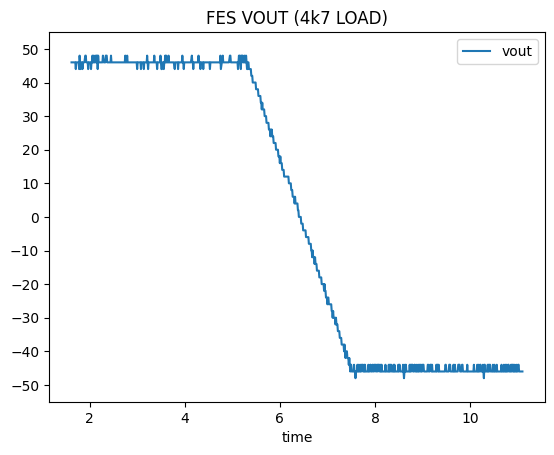

In [26]:
dados_4k7_vout_filtrado = dados_4k7_vout.query("vout < 50 & vout > -50").copy()

threshold = 5
mask = dados_4k7_vout_filtrado["vout"].abs() > threshold

vout_start = mask.idxmax()
vout_end = mask[::-1].idxmax()

dados_4k7_vout_filtrado = dados_4k7_vout_filtrado.loc[vout_start:vout_end].copy()

ax_vout = dados_4k7_vout_filtrado.plot(
    x="time",
    y="vout",
    ylim=(-55, 55),
    title="FES VOUT (4k7 LOAD)"
)

ax_vout.set_yticks(range(-50, 51, 10));

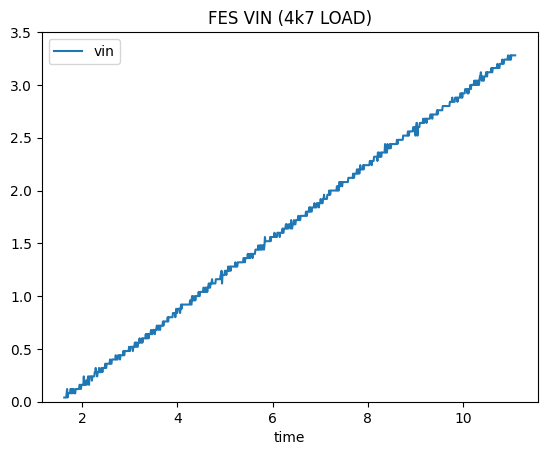

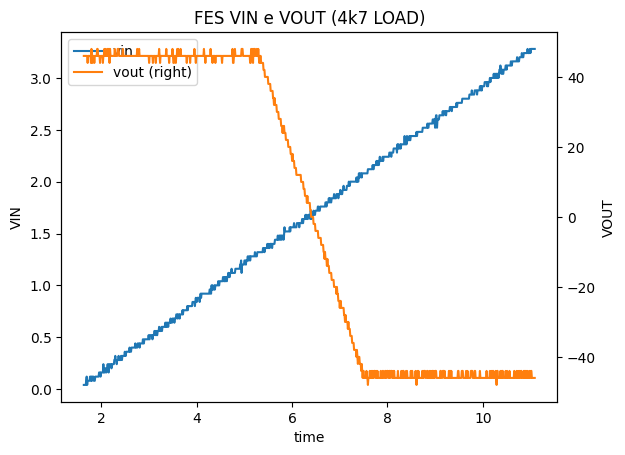

In [27]:
dados_4k7_vin_filtrado = dados_4k7_vin.query("vin < 3.3 & vin > 0").copy()

vin_base = 1.65
delta = 0.1

# Inicio: primeiro ponto que varia mais que delta em relacao a base
mask_start = (dados_4k7_vin_filtrado["vin"] - vin_base).abs() > delta
vin_start = mask_start[mask_start].index[0]

# Regiao apos o inicio
dados_pos_start = dados_4k7_vin_filtrado.loc[vin_start:]

# Pico da rampa
peak = dados_pos_start["vin"].idxmax()
vin_peak = dados_pos_start.loc[peak, "vin"]

# Final: primeiro ponto apos o pico que cai mais que delta
dados_pos_peak = dados_4k7_vin_filtrado.loc[peak:]

mask_end = (vin_peak - dados_pos_peak["vin"]) > delta
end_idx = mask_end[mask_end].index[0]

# Remove o primeiro ponto da queda
end_pos = dados_4k7_vin_filtrado.index.get_loc(end_idx)
vin_end = dados_4k7_vin_filtrado.index[end_pos - 1]

dados_4k7_vin_filtrado = dados_4k7_vin_filtrado.loc[vin_start:vin_end].copy()

ax_vin = dados_4k7_vin_filtrado.plot(
    x="time",
    y="vin",
    ylim=(0, 3.5),
    title="FES VIN (4k7 LOAD)"
)

ax_vin.set_yticks([i * 0.5 for i in range(0, 8)]);

dados_4k7_vin_vout_filtrado = pd.merge_asof(
    dados_4k7_vin_filtrado.sort_values("time"),
    dados_4k7_vout_filtrado.sort_values("time"),
    on="time",
    direction="nearest"
)

ax = dados_4k7_vin_vout_filtrado.plot(
    x="time",
    y=["vin", "vout"],
    secondary_y="vout",
    title="FES VIN e VOUT (4k7 LOAD)"
)

ax.set_ylabel("VIN")
ax.right_ax.set_ylabel("VOUT");

## Analise estatistica de linearidade
 
 Esta secao calcula estatisticas descritivas, correlacao de Pearson, regressao linear, metricas de residuos e erro percentual em relacao ao fundo de escala. Tambem estima a corrente de saida a partir de vout / carga quando a carga resistiva esta definida.

media  desvio_padrao  minimo  maximo  pico_a_pico  \
carga variavel                                                         
4k7   vin       1.672101       0.947266    0.04    3.28         3.24   
      vout      0.840549      42.085222  -48.00   48.00        96.00   
2k2   vin       1.668868       0.943402    0.04    3.28         3.24   
      vout      1.100529      37.962172  -48.00   48.00        96.00   
1k    vin       1.668717       0.939255    0.04    3.28         3.24   
      vout      0.555650      25.291643  -44.00   46.00        90.00   

                n_amostras  
carga variavel              
4k7   vin              947  
      vout             947  
2k2   vin              945  
      vout             945  
1k    vin             1177  
      vout            1177

,ganho_vout_por_vin,offset_vout,pearson,r2,rmse,erro_maximo_absoluto,erro_maximo_percentual_full_scale,erro_absoluto_medio,erro_medio,erro_maximo_percentual,full_scale,n_amostras
carga,,,,,,,,,,,,
4k7,-41.104501,69.571441,-0.925192,0.855979,15.962929,32.686500,34.048437,13.624564,-2.400989e-15,91.402000,96.0,947
2k2,-39.077919,66.316407,-0.971129,0.943092,9.051263,18.753290,19.534677,7.754694,1.924857e-15,62.856338,96.0,945
1k,-26.895741,45.437032,-0.998826,0.997653,1.224720,6.209543,6.899492,0.920424,1.654110e-15,42.005395,90.0,1177


,ganho_mA_por_vin,offset_mA,pearson,r2,rmse,erro_maximo_absoluto,erro_maximo_percentual_full_scale,erro_absoluto_medio,erro_medio,erro_maximo_percentual,full_scale,n_amostras
carga,,,,,,,,,,,,
4k7,-8.745638,14.802434,-0.925192,0.855979,3.396368,6.954574,34.048437,2.898843,-1.200495e-15,91.402000,20.425532,947
2k2,-17.762690,30.143821,-0.971129,0.943092,4.114210,8.524223,19.534677,3.524861,-7.218212e-16,62.856338,43.636364,945
1k,-26.895741,45.437032,-0.998826,0.997653,1.224720,6.209543,6.899492,0.920424,1.654110e-15,42.005395,90.000000,1177


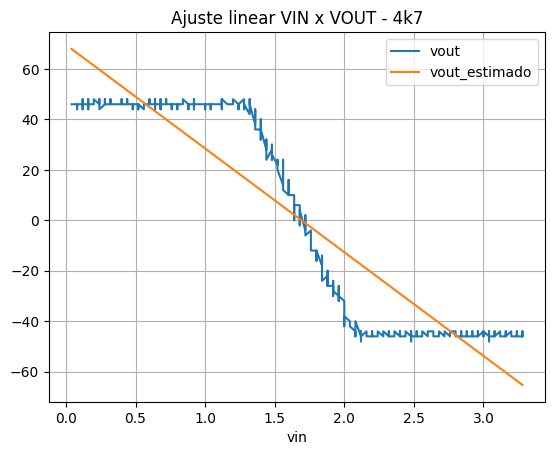

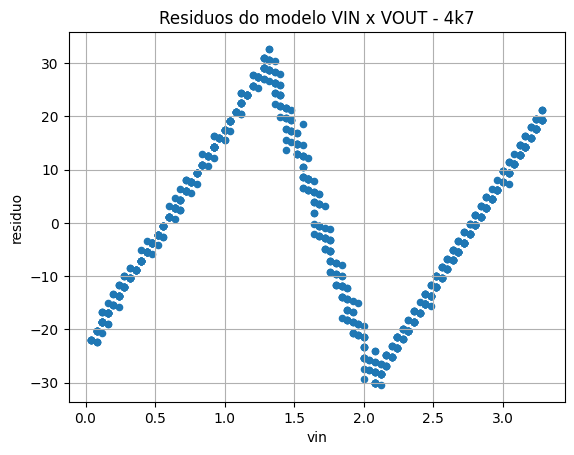

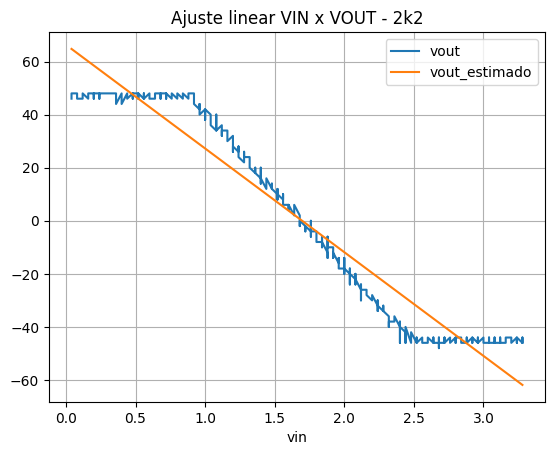

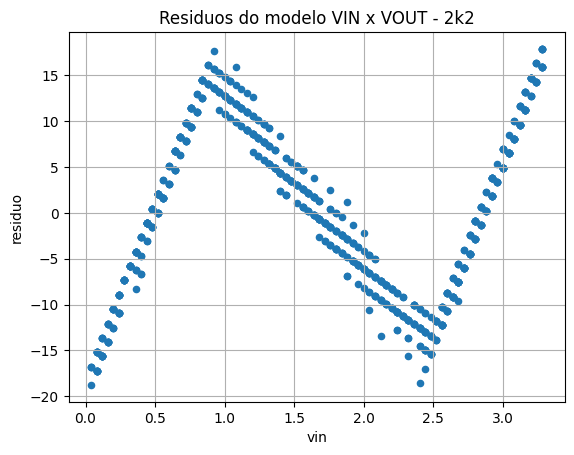

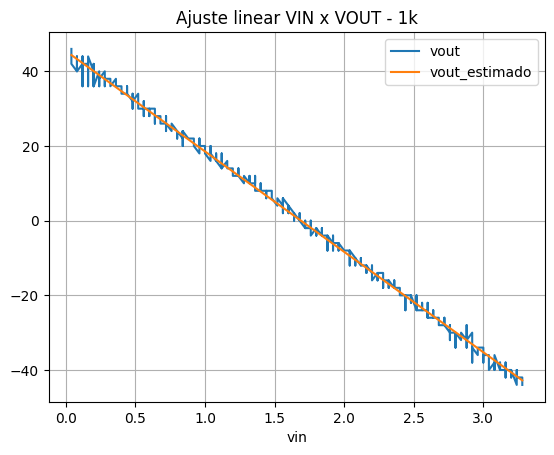

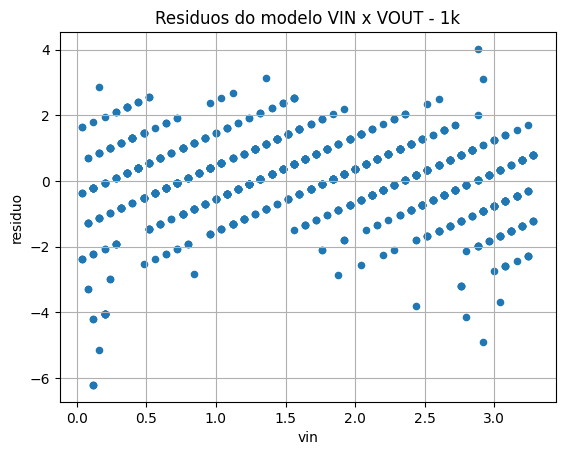

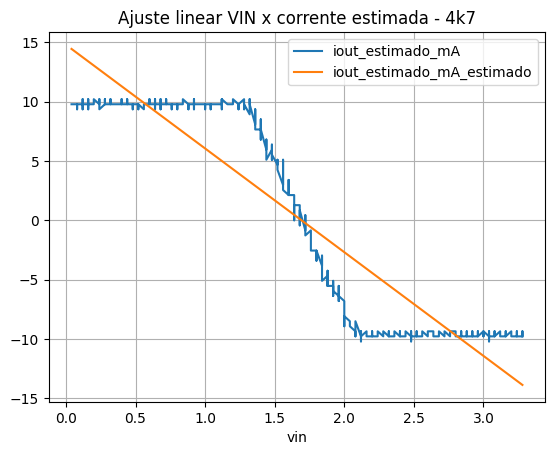

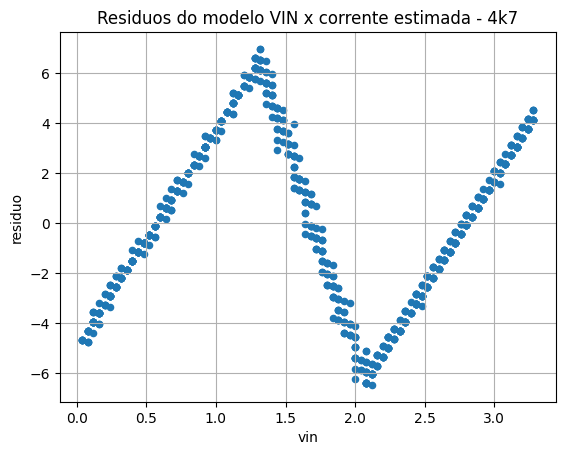

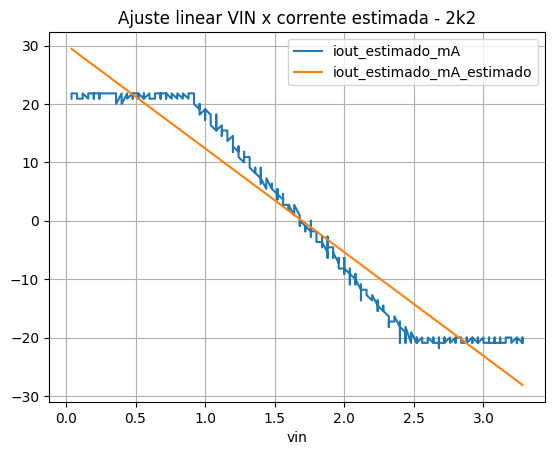

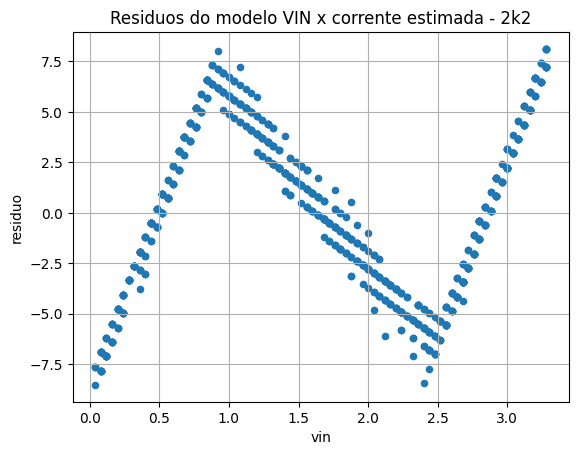

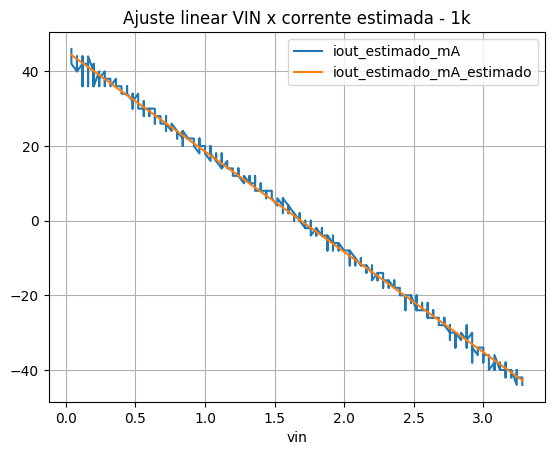

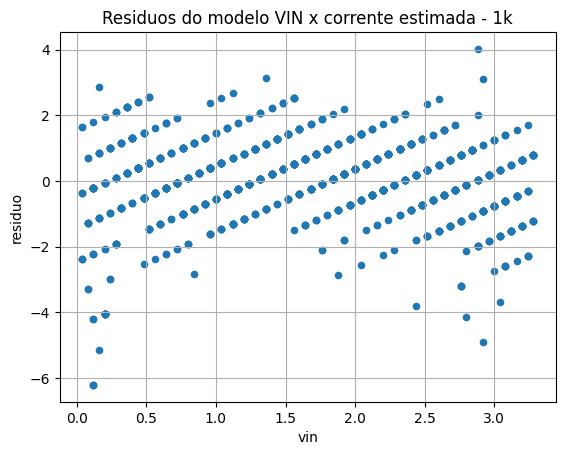

In [28]:
def carga_para_ohm(carga):
    texto = str(carga).lower().replace("_", "").replace("ohm", "")

    if "k" in texto:
        return float(texto.replace("k", ".")) * 1000
    if texto.endswith("r"):
        return float(texto[:-1])

    return float(texto)


def cargas_disponiveis():
    cargas_vin = {
        nome[len("dados_"):-len("_vin")]
        for nome in globals()
        if nome.startswith("dados_") and nome.endswith("_vin")
    }
    cargas_vout = {
        nome[len("dados_"):-len("_vout")]
        for nome in globals()
        if nome.startswith("dados_") and nome.endswith("_vout")
    }

    return sorted(cargas_vin & cargas_vout, key=carga_para_ohm, reverse=True)


def filtrar_vout(dados_vout, threshold=5):
    filtrado = dados_vout.query("vout < 50 & vout > -50").copy()
    mask = filtrado["vout"].abs() > threshold

    if not mask.any():
        return filtrado

    inicio = mask.idxmax()
    fim = mask[::-1].idxmax()

    return filtrado.loc[inicio:fim].copy()


def filtrar_vin(dados_vin, vin_base=1.65, delta=0.1):
    filtrado = dados_vin.query("vin < 3.3 & vin > 0").copy()
    mask_start = (filtrado["vin"] - vin_base).abs() > delta

    if not mask_start.any():
        return filtrado

    inicio = mask_start[mask_start].index[0]
    dados_pos_inicio = filtrado.loc[inicio:]

    pico = dados_pos_inicio["vin"].idxmax()
    vin_pico = dados_pos_inicio.loc[pico, "vin"]
    dados_pos_pico = filtrado.loc[pico:]

    mask_end = (vin_pico - dados_pos_pico["vin"]) > delta
    if not mask_end.any():
        return filtrado.loc[inicio:].copy()

    fim_idx = mask_end[mask_end].index[0]
    fim_pos = filtrado.index.get_loc(fim_idx)
    fim = filtrado.index[max(fim_pos - 1, 0)]

    return filtrado.loc[inicio:fim].copy()


def alinhar_vin_vout(dados_vin, dados_vout):
    return pd.merge_asof(
        dados_vin.sort_values("time"),
        dados_vout.sort_values("time"),
        on="time",
        direction="nearest",
    ).dropna(subset=["vin", "vout"])


def estatisticas_descritivas(df, colunas):
    linhas = []

    for coluna in colunas:
        serie = pd.to_numeric(df[coluna], errors="coerce").dropna()
        linhas.append({
            "variavel": coluna,
            "media": serie.mean(),
            "desvio_padrao": serie.std(),
            "minimo": serie.min(),
            "maximo": serie.max(),
            "pico_a_pico": serie.max() - serie.min(),
            "n_amostras": serie.count(),
        })

    return pd.DataFrame(linhas).set_index("variavel")


def analisar_linearidade(df, x_col, y_col, carga, limiar_zero_fs=0.05):
    dados = df[[x_col, y_col]].apply(pd.to_numeric, errors="coerce").dropna().copy()
    x = dados[x_col]
    y = dados[y_col]

    x_media = x.mean()
    y_media = y.mean()
    ss_x = ((x - x_media) ** 2).sum()
    ss_y = ((y - y_media) ** 2).sum()

    ganho = ((x - x_media) * (y - y_media)).sum() / ss_x
    offset = y_media - ganho * x_media

    y_estimado = ganho * x + offset
    residuo = y - y_estimado
    erro_abs = residuo.abs()

    ss_res = (residuo ** 2).sum()
    r2 = 1 - ss_res / ss_y
    pearson = x.corr(y)
    rmse = (ss_res / len(dados)) ** 0.5

    full_scale = y.max() - y.min()
    limiar_zero = max(abs(full_scale) * limiar_zero_fs, 1e-12)
    y_sem_zero = y.where(y.abs() >= limiar_zero)
    erro_percentual = 100 * residuo / y_sem_zero

    dados[f"{y_col}_estimado"] = y_estimado
    dados["residuo"] = residuo
    dados["erro_percentual"] = erro_percentual

    resumo = {
        "carga": carga,
        "x": x_col,
        "y": y_col,
        "ganho": ganho,
        "offset": offset,
        "pearson": pearson,
        "r2": r2,
        "erro_medio": residuo.mean(),
        "erro_absoluto_medio": erro_abs.mean(),
        "erro_maximo_absoluto": erro_abs.max(),
        "rmse": rmse,
        "erro_maximo_percentual": erro_percentual.abs().max(),
        "erro_maximo_percentual_full_scale": 100 * erro_abs.max() / abs(full_scale),
        "full_scale": full_scale,
        "n_amostras": len(dados),
        "limiar_zero_usado": limiar_zero,
    }

    return resumo, dados


cargas = {}
for carga in cargas_disponiveis():
    dados_vin = globals()[f"dados_{carga}_vin"].copy()
    dados_vout = globals()[f"dados_{carga}_vout"].copy()

    dados_vin.columns = ["time", "vin"]
    dados_vout.columns = ["time", "vout"]

    dados_vin_filtrado = filtrar_vin(dados_vin)
    dados_vout_filtrado = filtrar_vout(dados_vout)
    dados_vin_vout_filtrado = alinhar_vin_vout(dados_vin_filtrado, dados_vout_filtrado)

    globals()[f"dados_{carga}_vin_filtrado"] = dados_vin_filtrado
    globals()[f"dados_{carga}_vout_filtrado"] = dados_vout_filtrado
    globals()[f"dados_{carga}_vin_vout_filtrado"] = dados_vin_vout_filtrado

    cargas[carga] = {
        "df": dados_vin_vout_filtrado,
        "carga_ohm": carga_para_ohm(carga),
    }

estatisticas_lista = []
resumos_vout = []
resumos_corrente = []
residuos_por_carga = {}
residuos_corrente_por_carga = {}

for carga, info in cargas.items():
    df_carga = info["df"].copy()
    carga_ohm = info.get("carga_ohm")

    estatisticas_lista.append(
        estatisticas_descritivas(df_carga, ["vin", "vout"])
        .assign(carga=carga)
        .reset_index()
        .set_index(["carga", "variavel"])
    )

    resumo_vout, residuos_vout = analisar_linearidade(df_carga, "vin", "vout", carga)
    resumos_vout.append(resumo_vout)
    residuos_por_carga[carga] = residuos_vout

    if carga_ohm:
        df_corrente = df_carga.copy()
        df_corrente["iout_estimado_mA"] = 1000 * df_corrente["vout"] / carga_ohm
        resumo_corrente, residuos_corrente = analisar_linearidade(df_corrente, "vin", "iout_estimado_mA", carga)
        resumos_corrente.append(resumo_corrente)
        residuos_corrente_por_carga[carga] = residuos_corrente

estatisticas_por_carga = pd.concat(estatisticas_lista)

colunas_resultado = [
    "ganho",
    "offset",
    "pearson",
    "r2",
    "rmse",
    "erro_maximo_absoluto",
    "erro_maximo_percentual_full_scale",
    "erro_absoluto_medio",
    "erro_medio",
    "erro_maximo_percentual",
    "full_scale",
    "n_amostras",
]

resultados_linearidade = pd.DataFrame(resumos_vout).set_index("carga")[colunas_resultado]
resultados_corrente = pd.DataFrame(resumos_corrente).set_index("carga")[colunas_resultado]

comparativo_linearidade = resultados_linearidade.rename(columns={
    "ganho": "ganho_vout_por_vin",
    "offset": "offset_vout",
})

comparativo_corrente = resultados_corrente.rename(columns={
    "ganho": "ganho_mA_por_vin",
    "offset": "offset_mA",
})

display(estatisticas_por_carga)
display(comparativo_linearidade)
display(comparativo_corrente)

for carga, residuos in residuos_por_carga.items():
    residuos_ordenados = residuos.sort_values("vin")
    residuos_ordenados.plot(
        x="vin",
        y=["vout", "vout_estimado"],
        title=f"Ajuste linear VIN x VOUT - {carga}",
        grid=True,
    )
    residuos.plot.scatter(
        x="vin",
        y="residuo",
        title=f"Residuos do modelo VIN x VOUT - {carga}",
        grid=True,
    )

for carga, residuos in residuos_corrente_por_carga.items():
    residuos_ordenados = residuos.sort_values("vin")
    residuos_ordenados.plot(
        x="vin",
        y=["iout_estimado_mA", "iout_estimado_mA_estimado"],
        title=f"Ajuste linear VIN x corrente estimada - {carga}",
        grid=True,
    )
    residuos.plot.scatter(
        x="vin",
        y="residuo",
        title=f"Residuos do modelo VIN x corrente estimada - {carga}",
        grid=True,
    )